#### Clustering Assignment

In [11]:
# Balance - Number of miles eligible for award travel
# Qual_miles - Number of miles counted as qualifying for Topflight status
# cc1_miles - Number of miles earned with freq. flyer credit card in the past 12 months:
# cc2_miles - Number of miles earned with Rewards credit card in the past 12 months:
# cc3_miles - Number of miles earned with Small Business credit card in the past 12 months:
# note: miles bins: 1 = under 5,000
#       2 = 5,000 - 10,000
#       3 = 10,001 - 25,000
#       4 = 25,001 - 50,000
#       5 = over 50,000
# Bonus_miles - Number of miles earned from non-flight bonus transactions in the past 12 months
# Bonus_trans - Number of non-flight bonus transactions in the past 12 months
# Flight_miles_12mo - Number of flight miles in the past 12 months
# Flight_trans_12 - Number of flight transactions in the past 12 months
# Days_since_enroll - Number of days since Enroll_date
# Award - Dummy variable for Last_award (1 = not null, 0 = null)

Step 1: Data Preprocessing
Load the Data:

We'll load the dataset into a pandas DataFrame.
Handle Missing Values:

Check for missing values and handle them appropriately. In this case, it seems there are no missing values in the provided snippet.
Remove Outliers:

Use statistical methods like Z-score to identify and handle outliers.
Feature Scaling:

Scale the features using StandardScaler to ensure all features contribute equally to the distance calculations.

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the dataset
data = pd.read_csv('East West Airlines Data.csv')
df = pd.DataFrame(data)

# Display the first 5 rows
df.head()

# Check for missing values
df.isnull().sum()

ID                   0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award                0
dtype: int64

In [14]:
# Feature scaling
features = df.drop(columns=['ID', 'Award'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features

array([[-4.51140783e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01, -3.62167870e-01,  1.39545434e+00],
       [-5.39456874e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01, -3.62167870e-01,  1.37995704e+00],
       [-3.20031232e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01, -3.62167870e-01,  1.41192021e+00],
       ...,
       [-4.29480975e-05, -1.86298687e-01,  6.83121167e-01, ...,
        -3.28603258e-01, -3.62167870e-01, -1.31560393e+00],
       [-1.85606976e-01, -1.86298687e-01, -7.69578406e-01, ...,
         2.85309024e-02, -9.85033311e-02, -1.31608822e+00],
       [-7.00507951e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.28603258e-01, -3.62167870e-01, -1.31754109e+00]])

Step 2: Exploratory Data Analysis (EDA)
Perform EDA to understand the data distribution and identify potential clusters. Use visualizations like histograms and pair plots.

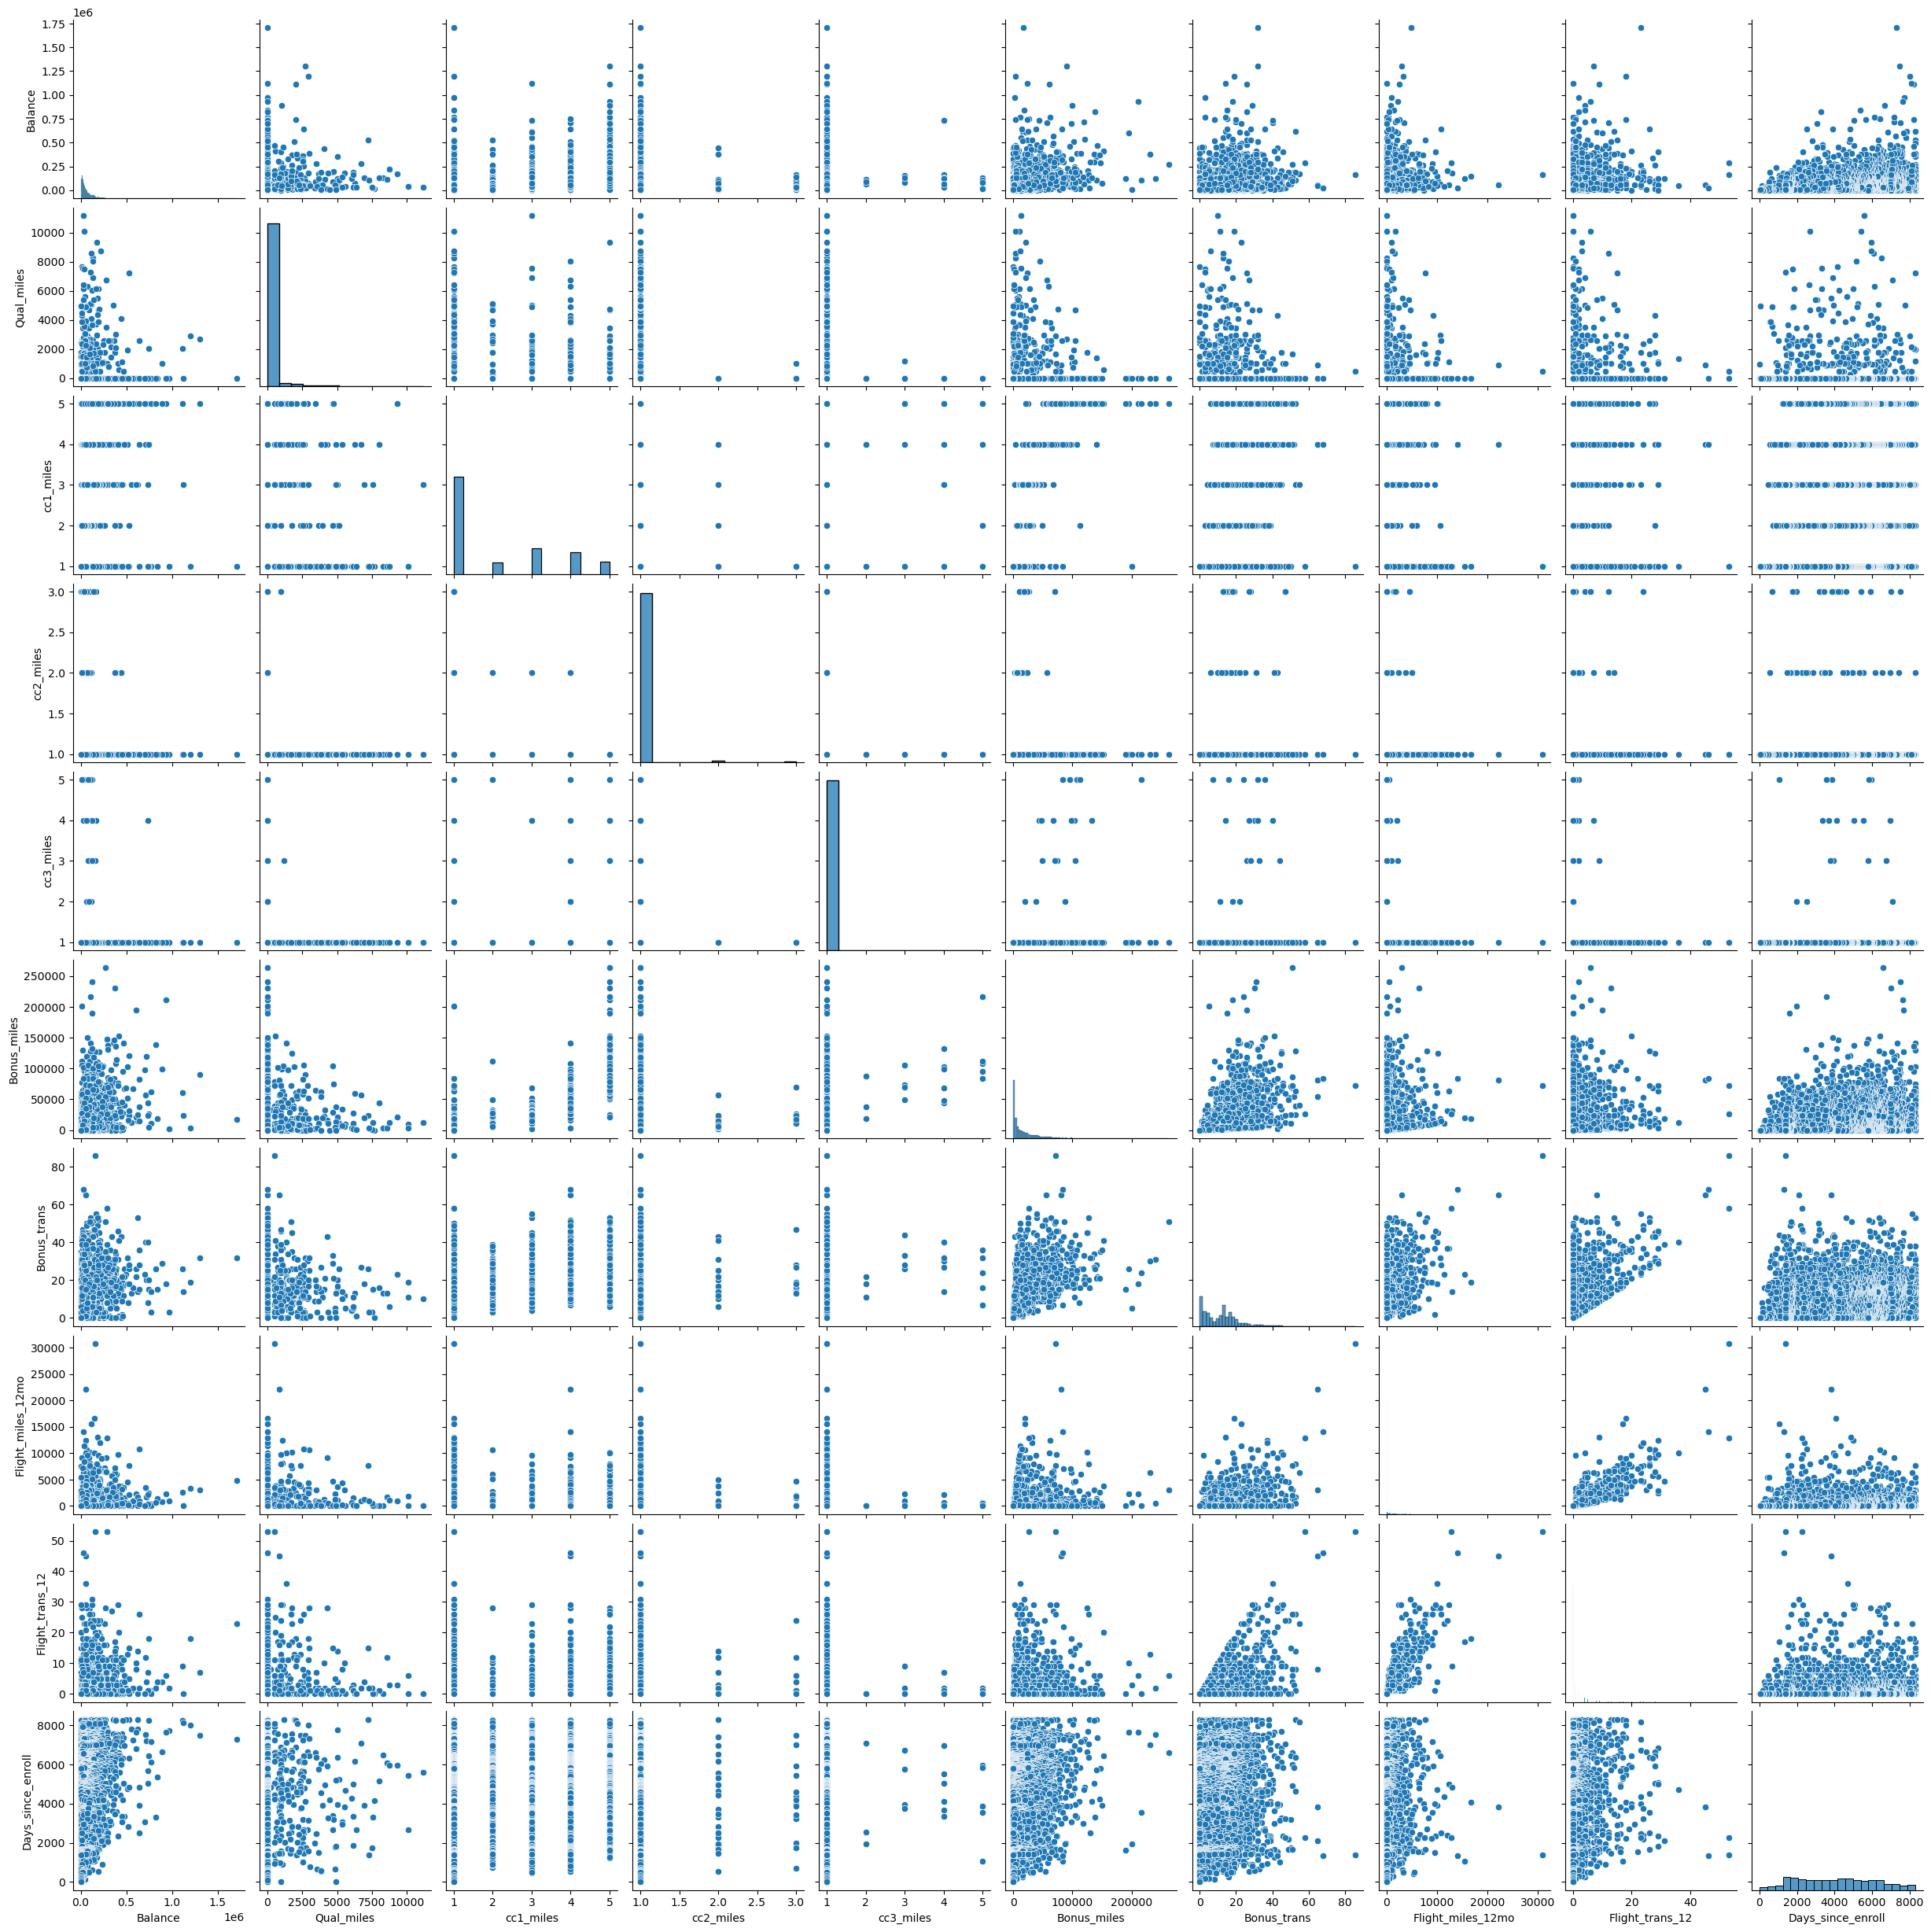

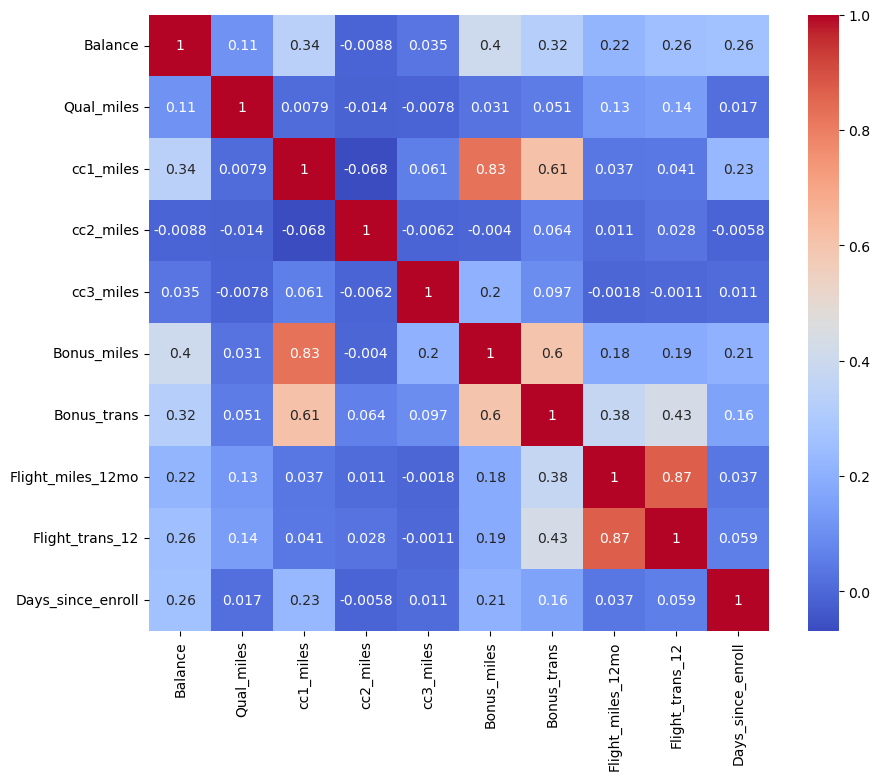

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pair plot to visualize relationships
sns.pairplot(df.drop(columns=['ID', 'Award']))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['ID', 'Award']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [17]:
# Step 3: Implementing Clustering Algorithms
# K-Means Clustering:
#
# Use the Elbow method to determine the optimal number of clusters.
# Hierarchical Clustering:
#
# Implement using AgglomerativeClustering and experiment with different linkage criteria.
# DBSCAN:
#
# Implement using DBSCAN and experiment with different eps and min_samples values.

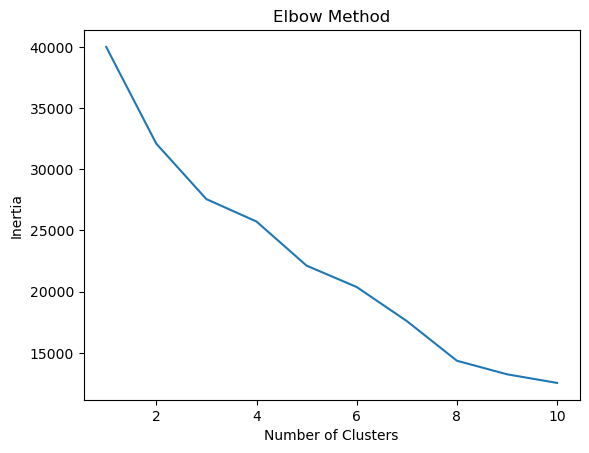

In [18]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# K-Means Clustering
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Apply K-Means with the chosen number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(scaled_features)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_clusters = hierarchical.fit_predict(scaled_features)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)
dbscan_clusters = dbscan.fit_predict(scaled_features)

inertia means the sum of squared distances of samples to their closest cluster center. The elbow method helps to determine the optimal number of clusters by looking for the "elbow" point where the inertia starts to decrease more slowly. In this case, we choose 3 clusters for K-Means clustering.

Step 4: Cluster Analysis and Interpretation
Analyze the characteristics of each cluster by examining the mean/median of features within clusters.


In [19]:
df['KMeans_Cluster'] = kmeans_clusters
df['Hierarchical_Cluster'] = hierarchical_clusters
df['DBSCAN_Cluster'] = dbscan_clusters

# Analyze clusters
print("K-Means Cluster Analysis:\n", df.groupby('KMeans_Cluster').mean())
print("\nHierarchical Cluster Analysis:\n", df.groupby('Hierarchical_Cluster').mean())
print("\nDBSCAN Cluster Analysis:\n", df.groupby('DBSCAN_Cluster').mean())

K-Means Cluster Analysis:
                          ID        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               2239.652243   42965.737991  112.915840   1.186582   1.019849   
1               1621.975019  117679.939440  124.538229   3.710825   1.001514   
2               1716.666667  192740.974843  801.031447   2.169811   1.037736   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.000397   4443.418023     6.783644         212.489083   
1                1.036336  39594.975776    18.884936         327.908403   
2                1.000000  31850.987421    27.427673        5480.100629   

                Flight_trans_12  Days_since_enroll     Award  \
KMeans_Cluster                                                 
0                      0.647479        3700.755855  0.244541   
1   

Step 5: Visualization
Visualize the clustering results using scatter plots.


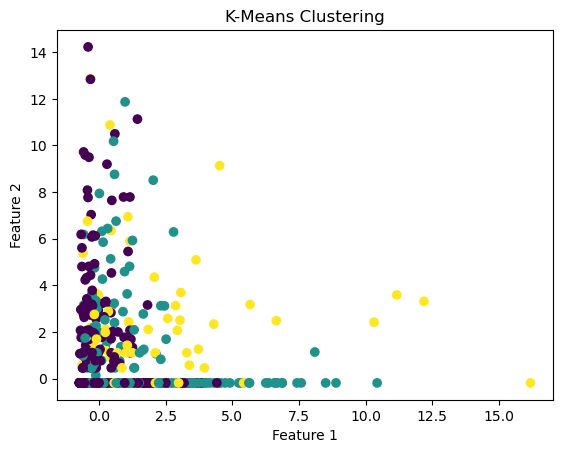

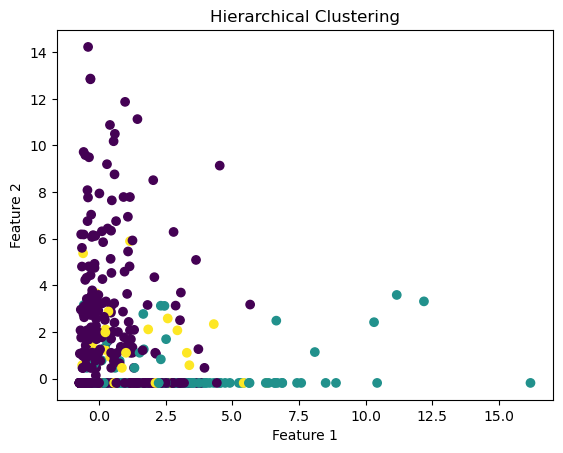

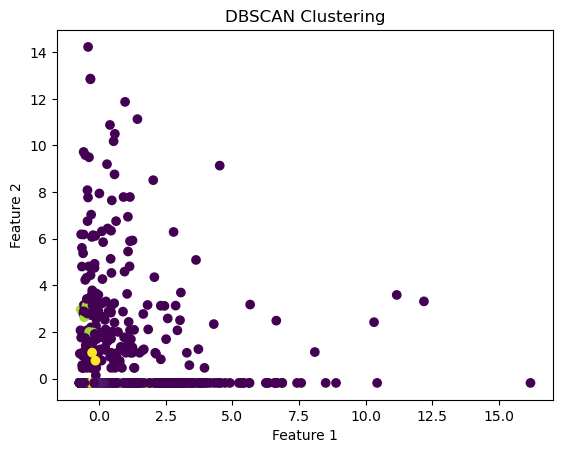

In [20]:
# Visualize K-Means Clustering
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=kmeans_clusters, cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Visualize Hierarchical Clustering
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=hierarchical_clusters, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Visualize DBSCAN Clustering
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=dbscan_clusters, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Step 6: Evaluation and Performance Metrics
Calculate the silhouette score for K-Means and DBSCAN.

In [21]:
# Silhouette Score
kmeans_silhouette = silhouette_score(scaled_features, kmeans_clusters)
dbscan_silhouette = silhouette_score(scaled_features, dbscan_clusters)

print(f'K-Means Silhouette Score: {kmeans_silhouette}')
print(f'DBSCAN Silhouette Score: {dbscan_silhouette}')

K-Means Silhouette Score: 0.33170243934542987
DBSCAN Silhouette Score: -0.25899854949760986


In [22]:
# The silhouette score ranges from -1 to 1, where a higher value indicates better-defined clusters. In this case, K-Means clustering has a higher silhouette score than DBSCAN.